# Análisis de Inversión Pública en Perú (2018–2025)

## Insights Finales

Este notebook presenta los principales hallazgos del análisis de inversión pública, enfocándose en ejecución, eficiencia, concentración y estructura de proyectos.


## 1. Carga del dataset (DAT)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.float_format = '{:,.2f}'.format
dat=pd.read_csv("../data/procesado/Det_inv_limpia.csv")

## 2. Concentración de la inversión

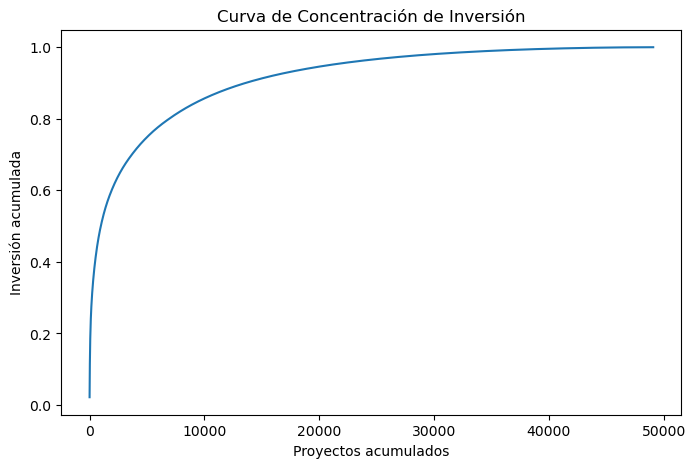

In [15]:
sorted_cost = np.sort(dat["COSTO_ACTUALIZADO"])[::-1]
cum_cost = np.cumsum(sorted_cost) / np.sum(sorted_cost)

plt.figure(figsize=(8,5))
plt.plot(cum_cost)
plt.title("Curva de Concentración de Inversión")
plt.xlabel("Proyectos acumulados")
plt.ylabel("Inversión acumulada")
plt.savefig("../outputs/concentracion.png", dpi=300, bbox_inches="tight")
plt.show()

Alta concentración de la inversión

- El 10% de los proyectos concentra el 75% del presupuesto
- El 1% concentra el 40%

La inversión pública depende fuertemente de un pequeño grupo de proyectos de gran escala.

## 3. Duración y Ejecución de proyectos

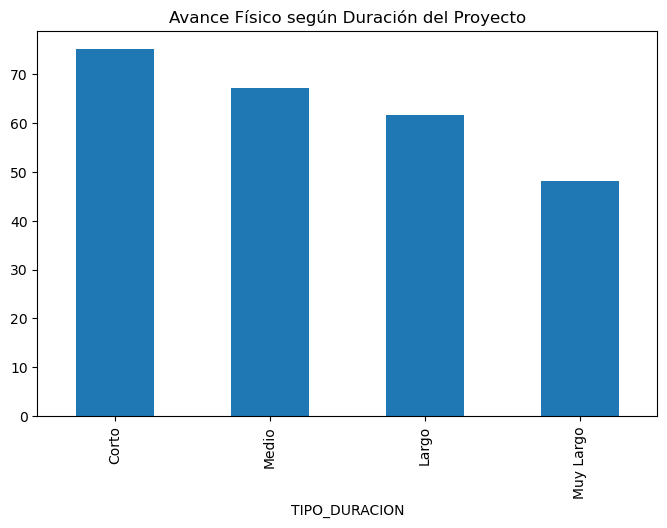

In [16]:
def clase_duracion(x):
    if x < 365:
        return "Corto"
    elif x < 730:
        return "Medio"
    elif x < 1460:
        return "Largo"
    else:
        return "Muy Largo"
dat["TIPO_DURACION"] = dat["DURACION_FISICA"].apply(clase_duracion)

orden_logico = ["Corto", "Medio", "Largo", "Muy Largo"]
dat["TIPO_DURACION"] = pd.Categorical(dat["TIPO_DURACION"], categories=orden_logico, ordered=True)

dat.groupby("TIPO_DURACION")["AVANCE_FISICO"].mean().plot(
    kind="bar",
    figsize=(8,5),
    title="Avance Físico según Duración del Proyecto"
)
plt.savefig("../outputs/avance_duracion.png", dpi=300, bbox_inches="tight")
plt.show()

Proyectos más largos ejecutan peor

- Cortos: 75%
- Muy largos: 48%

Existe una relación negativa entre duración y ejecución.

## 4. Eficiencia Social

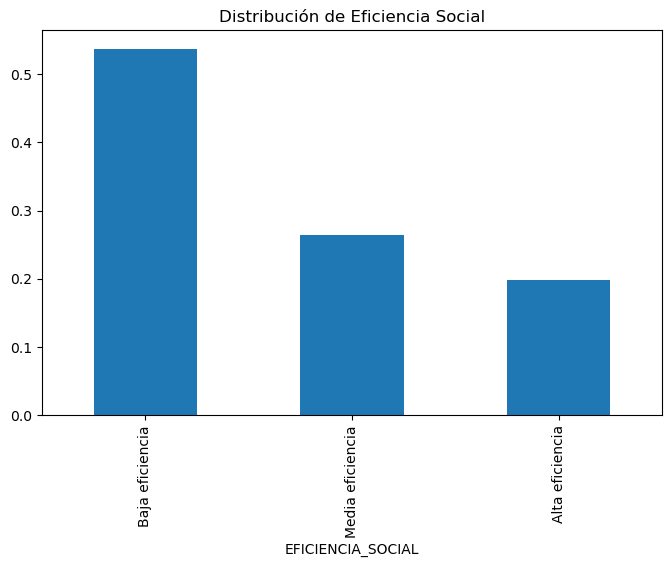

In [17]:
dat["COSTO_BEN"] = (dat["COSTO_ACTUALIZADO"] / dat["NUM_HABITANTES_BENEF"])
dat.loc[dat["NUM_HABITANTES_BENEF"] <= 0, "COSTO_BEN"] = None
dat["COSTO_BEN"] = dat["COSTO_BEN"].replace([np.inf, -np.inf], np.nan)

def clasificar_eficiencia(x):
    if x < 1000:
        return "Alta eficiencia"
    elif x < 10000:
        return "Media eficiencia"
    else:
        return "Baja eficiencia"

dat["EFICIENCIA_SOCIAL"] = dat["COSTO_BEN"].apply(clasificar_eficiencia)

dat["EFICIENCIA_SOCIAL"].value_counts(normalize=True).plot(
    kind="bar",
    figsize=(8,5),
    title="Distribución de Eficiencia Social"
)
plt.savefig("../outputs/eficiencia.png", dpi=300, bbox_inches="tight")
plt.show()

Baja eficiencia social

- 53.77% de proyectos presentan baja eficiencia
- 56% no tienen beneficiarios definidos

Existe una limitación importante en la formulación de proyectos.

## 5. Ejecución territorial

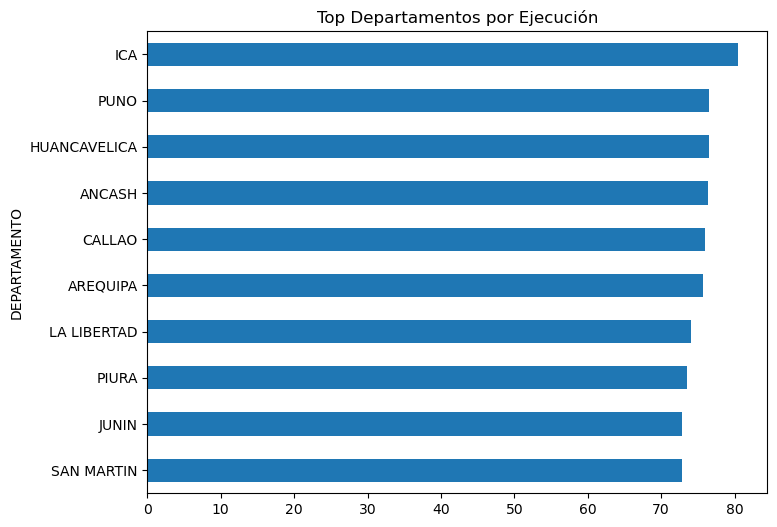

In [18]:
dat.groupby("DEPARTAMENTO")["AVANCE_EJECUCION"].mean().sort_values().tail(10).plot(
    kind="barh",
    figsize=(8,6),
    title="Top Departamentos por Ejecución"
)
plt.savefig("../outputs/territorial.png", dpi=300, bbox_inches="tight")
plt.show()

Ejecución territorial heterogénea

- La mayoría de departamentos tiene ejecución media-alta
- Los problemas se concentran en pocos territorios

La ineficiencia no es generalizada, sino focalizada.

## 6. Tamaño de inversión y su ejecución

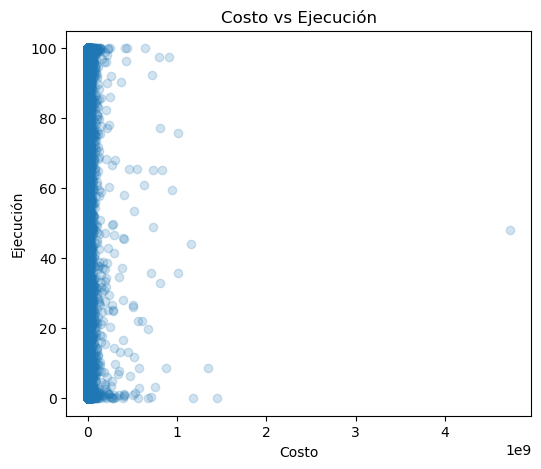

In [19]:
plt.figure(figsize=(6,5))
plt.scatter(dat["COSTO_ACTUALIZADO"], dat["AVANCE_EJECUCION"], alpha=0.2)
plt.xlabel("Costo")
plt.ylabel("Ejecución")
plt.title("Costo vs Ejecución")
plt.savefig("../outputs/costo_ejecucion.png", dpi=300, bbox_inches="tight")
plt.show()

Más inversión no implica mejor ejecución. No existe una relación positiva entre tamaño del proyecto y desempeño.

## 7. Hallazgo integrador

Los principales problemas de la inversión pública no están en la cantidad de recursos, sino en la estructura de los proyectos.

Los proyectos de gran escala:
- Son más largos
- Se ejecutan peor
- Concentran el presupuesto

Representan el principal riesgo del sistema.

## 8. Implicancias de Política Pública

- Rediseñar megaproyectos en fases
- Mejorar la formulación (beneficiarios)
- Focalizar supervisión en proyectos grandes
- Fortalecer capacidades en gobiernos locales

## 9. Conclusión

La inversión pública en Perú presenta desafíos estructurales asociados a la concentración y complejidad de los proyectos.

Si bien la mayoría de proyectos tiene desempeño aceptable, los problemas se concentran en un subconjunto crítico que afecta significativamente la eficiencia del gasto público.